In [1]:
%matplotlib inline
%load_ext autoreload
%autoreload 2
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import math
from math import sqrt
import ROOT
import ctypes
try:
#     plt.style.use('belle2')
    plt.style.use('belle2_serif')
#     plt.style.use('belle2_modern')
except OSError:
    print("Please install belle2 matplotlib style") 
px = 1/plt.rcParams['figure.dpi']

from main.data_tools.extract_ntuples import get_pd, get_np
from main.draw_tools.decorations import b2helix, watermark
from main.draw_tools.stacking_with_error_bars import MC_stack_plot, MC_stack_plot_density

from main.data_tools.error_bars import make_data_weight
from main.data_tools.query_dataframes import cut_dfs_7types

from matplotlib.ticker import ScalarFormatter


Welcome to JupyROOT 6.26/04


In [2]:
from math import sqrt

# Error-weighted combination function
def combine_error_weighted(x, y, x_err, y_err):
    central_value = (x / x_err**2 + y / y_err**2) / (1 / x_err**2 + 1 / y_err**2)
    error = 1 / sqrt(1 / x_err**2 + 1 / y_err**2)
    return central_value, error

In [3]:
# # signal_eff_error = math.sqrt(signal_eff * (1 - signal_eff) / N_gen)

# def calculate_sig_eff_err(eff, N_gen):

#     error = math.sqrt(eff * (1 - eff) / N_gen)
#     return error

In [4]:
def combine_x_plus_y_divided_by_2(x, y, x_err, y_err):
    central_value = (x+y)/2
    error = sqrt(x_err**2 +  y_err**2)/2
    return central_value, error

In [5]:
def correct_Acp_stats( Araw, Araw_err, Aref, Aref_err, Aref_pdg, Aref_K_mix):
    final_Acp = Araw - Aref + Aref_pdg + Aref_K_mix
    final_Acp_err = sqrt(Araw_err**2 + Aref_err**2)

    return final_Acp, final_Acp_err

In [6]:
def correct_Acp_stats_no_Kmix( Araw, Araw_err, Aref, Aref_err, Aref_pdg):
    final_Acp = Araw - Aref + Aref_pdg 
    final_Acp_err = sqrt(Araw_err**2 + Aref_err**2)

    return final_Acp, final_Acp_err

/tmp/ipykernel_10960/2146563861.py:8: RuntimeWarning: divide by zero encountered in true_divide
  y = x / np.sqrt(1 - x**2)


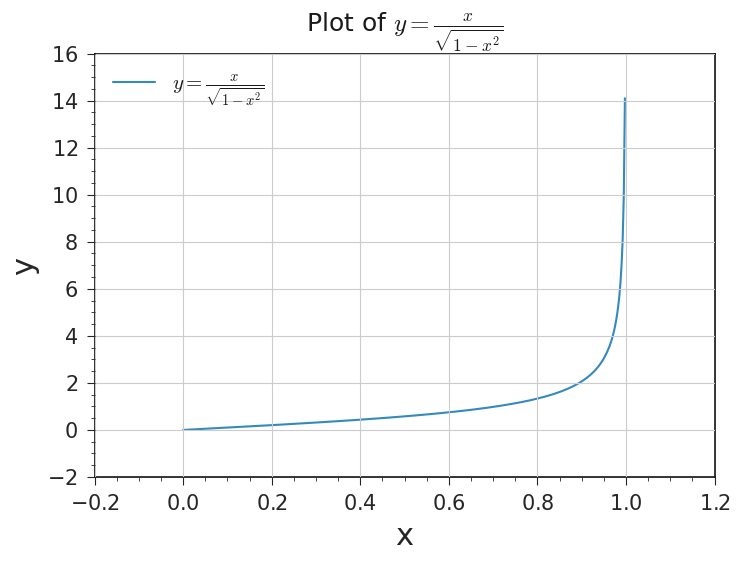

In [101]:
import numpy as np
import matplotlib.pyplot as plt

# Create an array of x values from 0 to 1
x = np.linspace(0, 1, 400)

# Calculate corresponding y values
y = x / np.sqrt(1 - x**2)

# Plot the function
plt.plot(x, y, label=r'$y = \frac{x}{\sqrt{1 - x^2}}$')
plt.xlabel('x')
plt.ylabel('y')
plt.title(r'Plot of $y = \frac{x}{\sqrt{1 - x^2}}$')
plt.grid(True)
plt.legend()
plt.show()


# MC15 full

## Acp(D+ -> eta pi+)

### eta -> gg

In [7]:
# Araw_gg_cms_plus = 0.0012959561431535693
# Araw_gg_cms_plus_error = 0.008847296239801952
# Araw_gg_cms_minus = 0.0036265431233290773
# Araw_gg_cms_minus_error =  0.01007268655495213
# Araw_gg, Araw_gg_stats_error = combine_x_plus_y_divided_by_2(Araw_gg_cms_plus,Araw_gg_cms_minus, Araw_gg_cms_plus_error,Araw_gg_cms_minus_error )

In [13]:
Araw_gg_cms_plus = 0.004948516184724424
Araw_gg_cms_plus_error =  0.009338569008183962
Araw_gg_cms_minus = 0.005612418226912087
Araw_gg_cms_minus_error =  0.010491502894555506
Araw_gg, Araw_gg_stats_error = combine_x_plus_y_divided_by_2(Araw_gg_cms_plus,Araw_gg_cms_minus, Araw_gg_cms_plus_error,Araw_gg_cms_minus_error )

In [14]:
Araw_gg

0.005280467205818255

In [15]:
Araw_gg_stats_error

0.007022828919087389

In [16]:
# Aref_gg_cms_plus = 0.004278295961374453
# Aref_gg_cms_plus_error = 0.0026385238818899975
# Aref_gg_cms_minus = 0.008913402855709032
# Aref_gg_cms_minus_error = 0.0028728539665111344
# Aref_gg, Aref_gg_stats_error = combine_x_plus_y_divided_by_2(Aref_gg_cms_plus,Aref_gg_cms_minus, Aref_gg_cms_plus_error,Aref_gg_cms_minus_error )

In [17]:
Aref_gg_cms_plus = -0.004683908275902915
Aref_gg_cms_plus_error = 0.002556644460775643
Aref_gg_cms_minus = 0.008672605054638093
Aref_gg_cms_minus_error = 0.0027853543878471336
Aref_gg, Aref_gg_stats_error = combine_x_plus_y_divided_by_2(Aref_gg_cms_plus,Aref_gg_cms_minus, Aref_gg_cms_plus_error,Aref_gg_cms_minus_error )

In [18]:
Aref_gg

0.001994348389367589

In [19]:
Aref_gg_stats_error

0.0018904119897997142

In [20]:
# Aref_gg = 0.0006061306395504472 
# Aref_gg_stats_error = 0.0018471929918681717

Aref_gg_pdg = -0.0041
Aref_gg_pdg_sys_error = 0.0009

# Aref_K_mix = -0.00070
# Aref_K_mix_sys_error = 0.00004

In [21]:
# Acp_etapip_gg_value, Acp_etapip_gg_error =correct_Acp_stats(Araw_gg, Araw_gg_stats_error, Aref_gg, Aref_gg_stats_error, Aref_gg_pdg, Aref_K_mix)
Acp_etapip_gg_value, Acp_etapip_gg_error = correct_Acp_stats_no_Kmix(Araw_gg, Araw_gg_stats_error, Aref_gg, Aref_gg_stats_error, Aref_gg_pdg)

In [22]:
Acp_etapip_gg_value

-0.000813881183549334

In [23]:
Acp_etapip_gg_error

0.007272811252737737

### eta -> pipipi

In [25]:
Araw_pipipi_cms_plus = -0.0029879681543246556
Araw_pipipi_cms_plus_error =  0.011940221357174546
Araw_pipipi_cms_minus = 0.008296772848536211
Araw_pipipi_cms_minus_error =  0.013096391936825668
Araw_pipipi, Araw_pipipi_stats_error = combine_x_plus_y_divided_by_2(Araw_pipipi_cms_plus,Araw_pipipi_cms_minus, Araw_pipipi_cms_plus_error,Araw_pipipi_cms_minus_error )

In [26]:
Araw_pipipi

0.0026544023471057774

In [27]:
Araw_pipipi_stats_error

0.008861212781291277

In [76]:
Aref_3pi_cms_plus = -0.00552483366458372
Aref_3pi_cms_plus_error =  0.0023102743117730043
Aref_3pi_cms_minus = 0.009282054494953057
Aref_3pi_cms_minus_error =   0.0025272609499480403
Aref_pipipi, Aref_pipipi_stats_error = combine_x_plus_y_divided_by_2(Aref_3pi_cms_plus,Aref_3pi_cms_minus, Aref_3pi_cms_plus_error,Aref_3pi_cms_minus_error )

In [77]:
Aref_pipipi

0.0018786104151846685

In [78]:
Aref_pipipi_stats_error

0.0017120466775741323

In [31]:
# Aref_pipipi = 0.0003791615573990744
# Aref_pipipi_stats_error = 0.0016987754151532451

Aref_pipipi_pdg = -0.0041
Aref_pipipi_pdg_sys_error = 0.0009

# Aref_K_mix = -0.00070
# Aref_K_mix_sys_error = 0.00004

In [32]:
# Acp_etapip_pipipi_value, Acp_etapip_pipipi_error =correct_Acp_stats(Araw_pipipi, Araw_pipipi_stats_error, Aref_pipipi, Aref_pipipi_stats_error, Aref_pipipi_pdg, Aref_K_mix)
Acp_etapip_pipipi_value, Acp_etapip_pipipi_error =correct_Acp_stats_no_Kmix(Araw_pipipi, Araw_pipipi_stats_error, Aref_pipipi, Aref_pipipi_stats_error, Aref_pipipi_pdg)

In [33]:
Acp_etapip_pipipi_value

-0.0033242080680788914

In [34]:
Acp_etapip_pipipi_error

0.009025087023486948

In [35]:
central_value_1, central_value_2, stat_unc_1, stat_unc_2 = Acp_etapip_gg_value, Acp_etapip_pipipi_value, Acp_etapip_gg_error, Acp_etapip_pipipi_error

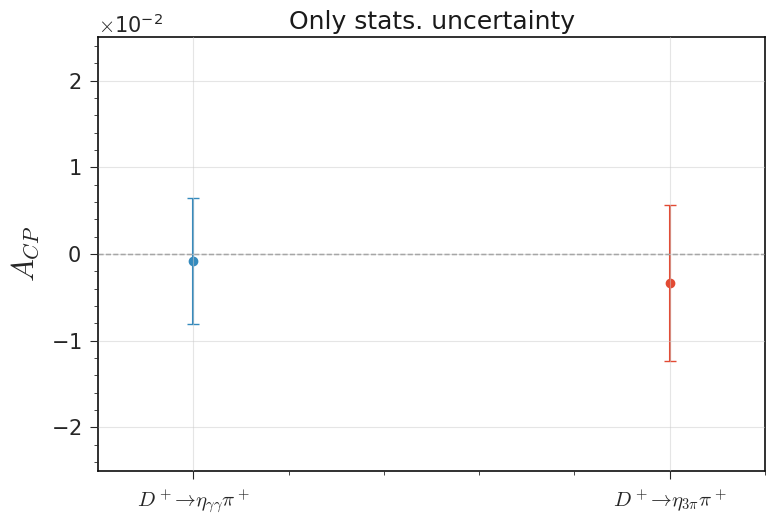

In [36]:
# Plotting
plt.errorbar(1, central_value_1, yerr=stat_unc_1, fmt='o', capsize=4)
plt.errorbar(2, central_value_2, yerr=stat_unc_2, fmt='o', capsize=4)
# plt.errorbar(3, combined_central_value, yerr=combined_error, fmt='o', capsize=4)

plt.axhline(y=0, color='gray', linestyle='--', linewidth=1)

# plt.xticks([1, 2, 3], [r'$D^+ \to \eta_{\gamma\gamma} \pi^+$', r'$D^+ \to \eta_{3\pi} \pi^+$', 'Combined'], fontsize=14)
plt.xticks([1, 2], [r'$D^+ \to \eta_{\gamma\gamma} \pi^+$', r'$D^+ \to \eta_{3\pi} \pi^+$'])

plt.gca().yaxis.set_major_formatter(ScalarFormatter(useMathText=True))
plt.ticklabel_format(axis="y", style="sci", scilimits=(0,0))

plt.ylabel(r'$A_{CP}$')
plt.grid(True, alpha=0.5)
plt.title("Only stats. uncertainty")

plt.ylim(-2.5*0.01 , 2.5*0.01)
plt.tight_layout()
plt.savefig("MC15rd_427_87_etapip_Acp_v7_fitv6_corr.png")
plt.show()

In [37]:
combined_central_value, combined_error = combine_error_weighted(central_value_1, central_value_2, stat_unc_1, stat_unc_2)


In [38]:
combined_central_value

-0.0018022299788163722

In [39]:
combined_error

0.00566293241145614

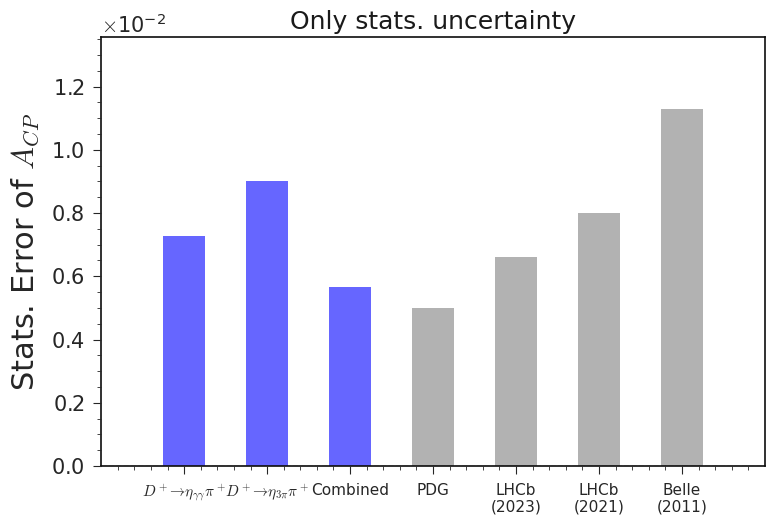

In [40]:
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter

# Define the errors as bar heights
errors = [stat_unc_1, stat_unc_2, combined_error, 0.005, 0.0066, 0.008,0.0113]

colors = ['blue', 'blue', 'blue', 'gray', 'gray', 'gray', 'gray', 'gray']

# Plotting error bars as a bar graph
plt.bar([1, 2, 3, 4, 5, 6,7], errors, color=colors , alpha=0.6, width=0.5)

# Adding a horizontal line at y=0
plt.axhline(y=0, color='gray', linestyle='--', linewidth=1)

# Customizing plot
plt.xticks([1, 2, 3, 4, 5, 6, 7], [r'$D^+ \to \eta_{\gamma\gamma} \pi^+$', r'$D^+ \to \eta_{3\pi} \pi^+$', 'Combined','PDG','LHCb\n(2023)','LHCb\n(2021)', 'Belle\n(2011)'], fontsize=11)
plt.gca().yaxis.set_major_formatter(ScalarFormatter(useMathText=True))
plt.ticklabel_format(axis="y", style="sci", scilimits=(0,0))

plt.ylabel(r'Stats. Error of $A_{CP}$')
# plt.grid(True, alpha=0.5)
plt.title("Only stats. uncertainty")

plt.ylim(0, max(errors) * 1.2)  # Adjusting y-limit to show error bars fully
plt.tight_layout()

# Save and display
# plt.savefig("MC15rd_427_87_etapip_Acp_error_bars_v7_fitv1_corr_Kshp.png")
# plt.savefig("MC15rd_427_87_etapip_Acp_error_bars_v7_fitv1_corr_pdg_Kshp_bdt_Dp_CMS_p_newFOM_pdgKsmix.png")
plt.savefig("MC15rd_427_87_etapip_Acp_error_bars_v7_fitv6_corr.png")

plt.show()


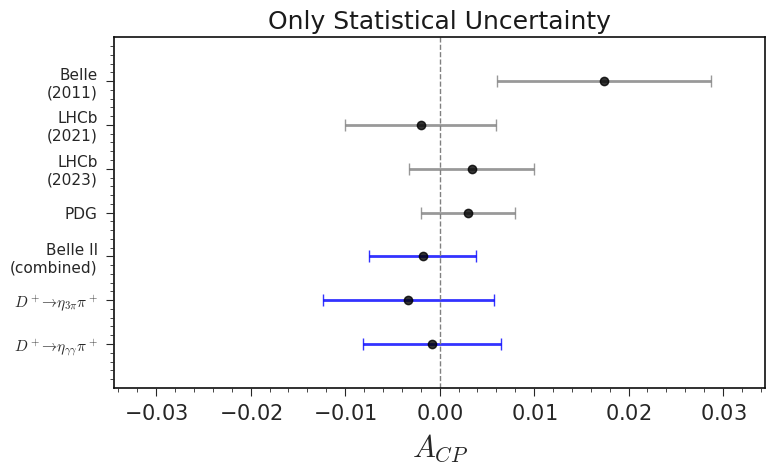

In [63]:
import matplotlib.pyplot as plt

# 중심값과 에러 (예시값, 실제 값으로 교체하세요)
central_values = [Acp_etapip_gg_value, Acp_etapip_pipipi_value, combined_central_value, 0.003, 0.0034, -0.002, 0.0174]
stat_errors = [stat_unc_1, stat_unc_2, combined_error, 0.005, 0.0066, 0.008, 0.0113]

labels = [
    r'$D^+ \to \eta_{\gamma\gamma} \pi^+$',
    r'$D^+ \to \eta_{3\pi} \pi^+$',
    'Belle II\n(combined)',
    'PDG',
    'LHCb\n(2023)',
    'LHCb\n(2021)',
    'Belle\n(2011)'
]

colors = ['blue', 'blue', 'blue', 'gray', 'gray', 'gray', 'gray']
y_positions = list(range(len(central_values)))

plt.figure(figsize=(8, 5))
for y, x, err, color in zip(y_positions, central_values, stat_errors, colors):
    plt.errorbar(
        x=x, y=y,
        xerr=err, fmt='o', color='black',
        ecolor=color, elinewidth=2, capsize=4, alpha=0.8
    )

plt.yticks(y_positions, labels, fontsize=11)
plt.xlabel(r'$A_{CP}$')
plt.title('Only Statistical Uncertainty')
plt.axvline(x=0, color='gray', linestyle='--', linewidth=1)

# ❗ Add symmetric x-axis limits
max_extent = max(abs(x) + err for x, err in zip(central_values, stat_errors))
plt.xlim(-1.2 * max_extent, 1.2 * max_extent)

plt.tight_layout()
plt.savefig("MC15rd_427_87_etapip_Acp_error_bars_v7_fitv6.png")
plt.show()


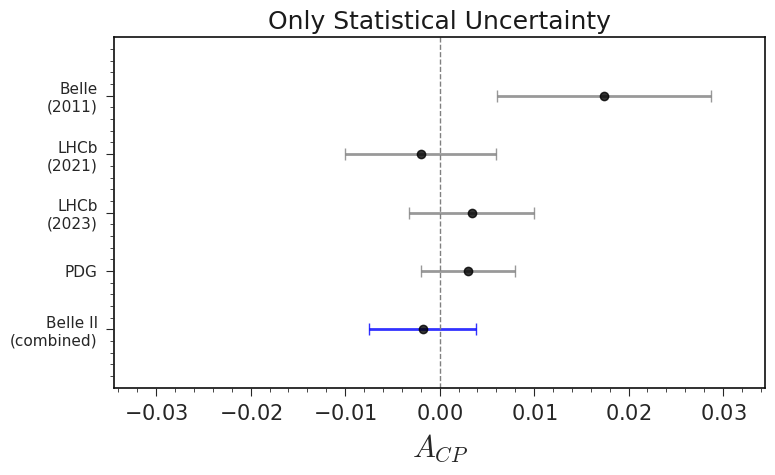

In [64]:
import matplotlib.pyplot as plt

# 중심값과 에러 (예시값, 실제 값으로 교체하세요)
central_values = [combined_central_value, 0.003, 0.0034, -0.002, 0.0174]
stat_errors = [ combined_error, 0.005, 0.0066, 0.008, 0.0113]

labels = [
    # r'$D^+ \to \eta_{\gamma\gamma} \pi^+$',
    # r'$D^+ \to \eta_{3\pi} \pi^+$',
    'Belle II\n(combined)',
    'PDG',
    'LHCb\n(2023)',
    'LHCb\n(2021)',
    'Belle\n(2011)'
]

colors = ['blue', 'gray', 'gray', 'gray', 'gray']
y_positions = list(range(len(central_values)))

plt.figure(figsize=(8, 5))
for y, x, err, color in zip(y_positions, central_values, stat_errors, colors):
    plt.errorbar(
        x=x, y=y,
        xerr=err, fmt='o', color='black',
        ecolor=color, elinewidth=2, capsize=4, alpha=0.8
    )

plt.yticks(y_positions, labels, fontsize=11)
plt.xlabel(r'$A_{CP}$')
plt.title('Only Statistical Uncertainty')
plt.axvline(x=0, color='gray', linestyle='--', linewidth=1)

# ❗ Add symmetric x-axis limits
max_extent = max(abs(x) + err for x, err in zip(central_values, stat_errors))
plt.xlim(-1.2 * max_extent, 1.2 * max_extent)

plt.tight_layout()
plt.savefig("MC15rd_427_87_etapip_Acp_error_bars_v7_fitv6_only_combined.png")
plt.show()


## Acp(Ds+ -> eta pi+)

### eta -> gg

In [65]:
Araw_gg_cms_plus = -0.0046841451405230956
Araw_gg_cms_plus_error = 0.005683522198995341
Araw_gg_cms_minus = 0.012201114194358051
Araw_gg_cms_minus_error = 0.0062251258344969505
Araw_gg, Araw_gg_stats_error = combine_x_plus_y_divided_by_2(Araw_gg_cms_plus,Araw_gg_cms_minus, Araw_gg_cms_plus_error,Araw_gg_cms_minus_error )

In [66]:
Araw_gg

0.003758484526917478

In [67]:
Araw_gg_stats_error

0.004214695013930255

In [173]:
# Aref_gg = 0.0020477180350933996
# Aref_gg_stats_error = 0.0021030268194965596

# Aref_gg_pdg = -0.0038
# Aref_gg_pdg_sys_error = 0.0027


In [174]:
# Acp_etapip_gg_value, Acp_etapip_gg_error =correct_Acp_stats_no_Kmix(Araw_gg, Araw_gg_stats_error, Aref_gg, Aref_gg_stats_error, Aref_gg_pdg)

In [175]:
Aref_gg_pdg = -0.0041
Aref_gg_pdg_sys_error = 0.0009

In [176]:
Acp_etapip_gg_value, Acp_etapip_gg_error =correct_Acp_stats(Araw_gg, Araw_gg_stats_error, Aref_gg, Aref_gg_stats_error, Aref_gg_pdg, Aref_K_mix)

In [177]:
Acp_etapip_gg_value

-0.005372714300189914

In [178]:
Acp_etapip_gg_error

0.004465442194885353

### eta -> pipipi

In [179]:
# Araw_pipipi =  0.0003362131000147013
# Araw_pipipi_stats_error = 0.005709802050462188

In [71]:
Araw_3pi_cms_plus = -0.0013997647956182858
Araw_3pi_cms_plus_error = 0.007518682999767889
Araw_3pi_cms_minus = 0.006308559656329701
Araw_3pi_cms_minus_error = 0.008242413143563727
Araw_pipipi, Araw_pipipi_stats_error = combine_x_plus_y_divided_by_2(Araw_3pi_cms_plus,Araw_3pi_cms_minus, Araw_3pi_cms_plus_error,Araw_3pi_cms_minus_error )

In [74]:
Araw_pipipi

0.0024543974303557073

In [75]:
Araw_pipipi_stats_error

0.005578260671575656

In [72]:
Aref_pipipi

0.0018786104151846685

In [73]:
Aref_pipipi_stats_error

0.0017120466775741323

In [184]:
# Aref_pipipi = 0.0020154684957205933
# Aref_pipipi_stats_error = 0.0019261952673341304

# Aref_pipipi_pdg = -0.0038
# Aref_pipipi_pdg_sys_error = 0.0027



In [185]:
# Acp_etapip_pipipi_value, Acp_etapip_pipipi_error =correct_Acp_stats_no_Kmix(Araw_pipipi, Araw_pipipi_stats_error, Aref_pipipi, Aref_pipipi_stats_error, Aref_pipipi_pdg)

In [18]:
# Aref_pipipi_pdg = -0.0041
# Aref_pipipi_pdg_sys_error = 0.0009

# Aref_K_mix = -0.00070
# Aref_K_mix_sys_error = 0.00004

In [19]:
# Acp_etapip_pipipi_value, Acp_etapip_pipipi_error =correct_Acp_stats(Araw_pipipi, Araw_pipipi_stats_error, Aref_pipipi, Aref_pipipi_stats_error, Aref_pipipi_pdg, Aref_K_mix)


In [20]:
Aref_pipipi_pdg = -0.0041
Aref_pipipi_pdg_sys_error = 0.0009

Aref_3pi_cms_plus = -0.018859111446337753
Aref_3pi_cms_plus_error =  0.0020677090241932126
Aref_3pi_cms_minus = 0.02252220703128427
Aref_3pi_cms_minus_error =  0.002331491411569646
Aref_pipipi, Aref_pipipi_stats_error = combine_x_plus_y_divided_by_2(Aref_3pi_cms_plus,Aref_3pi_cms_minus, Aref_3pi_cms_plus_error,Aref_3pi_cms_minus_error )

In [21]:
Aref_pipipi

0.0018315477924732582

In [22]:
Aref_pipipi_stats_error

0.00155814575786037

In [188]:
Acp_etapip_pipipi_value

-0.00485945512384441

In [189]:
Acp_etapip_pipipi_error

0.005824025805697502

In [190]:
central_value_1, central_value_2, stat_unc_1, stat_unc_2 = Acp_etapip_gg_value, Acp_etapip_pipipi_value, Acp_etapip_gg_error, Acp_etapip_pipipi_error

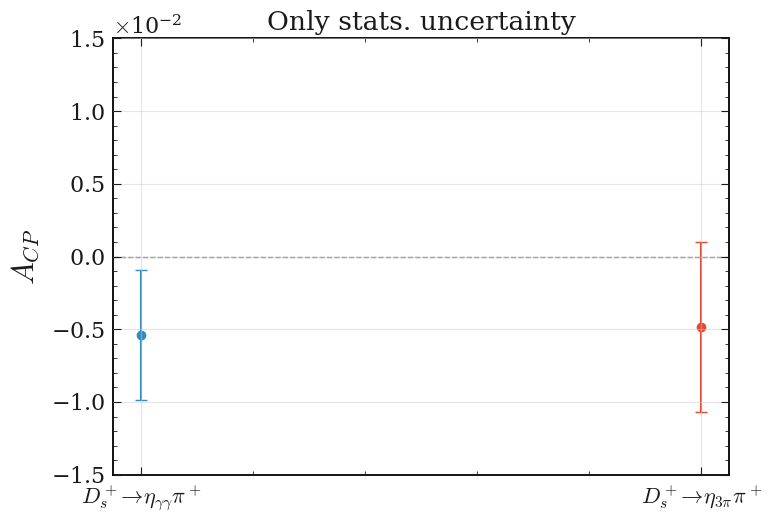

In [191]:
# Plotting
plt.errorbar(1, central_value_1, yerr=stat_unc_1, fmt='o', capsize=4)
plt.errorbar(2, central_value_2, yerr=stat_unc_2, fmt='o', capsize=4)
# plt.errorbar(3, combined_central_value, yerr=combined_error, fmt='o', capsize=4)

plt.axhline(y=0, color='gray', linestyle='--', linewidth=1)

# plt.xticks([1, 2, 3], [r'$D_s^+ \to \eta_{\gamma\gamma} \pi^+$', r'$D_s^+ \to \eta_{3\pi} \pi^+$', 'Combined'], fontsize=14)
plt.xticks([1, 2], [r'$D_s^+ \to \eta_{\gamma\gamma} \pi^+$', r'$D_s^+ \to \eta_{3\pi} \pi^+$'])

plt.gca().yaxis.set_major_formatter(ScalarFormatter(useMathText=True))
plt.ticklabel_format(axis="y", style="sci", scilimits=(0,0))

plt.ylabel(r'$A_{CP}$')
plt.grid(True, alpha=0.5)
plt.title("Only stats. uncertainty")

plt.ylim(-1.5*0.01 , 1.5*0.01)

plt.tight_layout()
# plt.savefig("MC15rd_427_87_etapip_Acp_v7_fitv1_corr_Phipip_Ds.png")
plt.savefig("MC15rd_427_87_etapip_Acp_v7_fitv1_corr_pdg_Kshp_bdt_Dp_CMS_p_newFOM_pdgKsmix_Ds.png")

plt.show()

In [192]:
combined_central_value, combined_error = combine_error_weighted(central_value_1, central_value_2, stat_unc_1, stat_unc_2)


In [193]:
combined_central_value

-0.005182692360291828

In [194]:
combined_error

0.003543698812017913

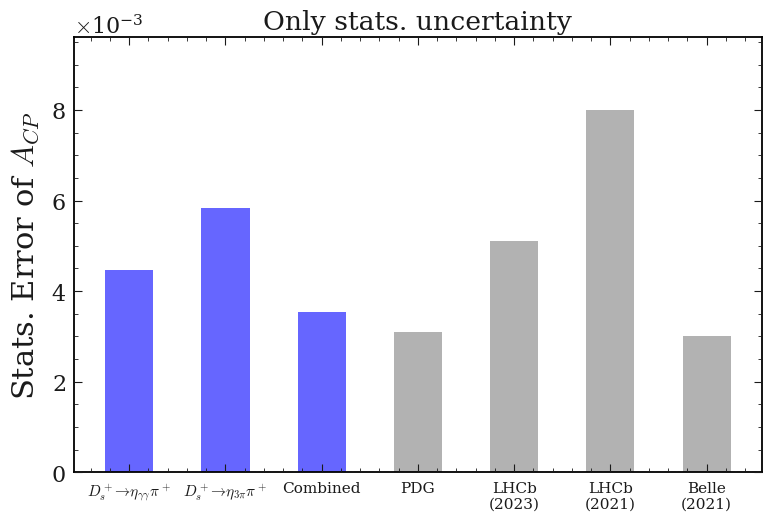

In [195]:
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter

# Define the errors as bar heights
errors = [stat_unc_1, stat_unc_2, combined_error, 0.0031,0.0051, 0.008, 0.003]

colors = ['blue', 'blue', 'blue', 'gray', 'gray', 'gray', 'gray','gray']
# Plotting error bars as a bar graph
plt.bar([1, 2, 3, 4, 5, 6, 7], errors, color=colors, alpha=0.6, width=0.5)

# Adding a horizontal line at y=0
plt.axhline(y=0, color='gray', linestyle='--', linewidth=1)

# Customizing plot
plt.xticks([1, 2, 3, 4, 5, 6,7], [r'$D_s^+ \to \eta_{\gamma\gamma} \pi^+$', r'$D_s^+ \to \eta_{3\pi} \pi^+$', 'Combined','PDG','LHCb\n(2023)','LHCb\n(2021)','Belle\n(2021)'], fontsize=11)
plt.gca().yaxis.set_major_formatter(ScalarFormatter(useMathText=True))
plt.ticklabel_format(axis="y", style="sci", scilimits=(0,0))

plt.ylabel(r'Stats. Error of $A_{CP}$')
# plt.grid(True, alpha=0.5)
plt.title("Only stats. uncertainty")

plt.ylim(0, max(errors) * 1.2)  # Adjusting y-limit to show error bars fully
plt.tight_layout()


# Save and display
# plt.savefig("MC15rd_427_87_etapip_Acp_error_bars_v7_fitv1_corr_Phipip_Ds.png")
plt.savefig("MC15rd_427_87_etapip_Acp_error_bars_v7_fitv1_corr_pdg_Kshp_bdt_Dp_CMS_p_newFOM_pdgKsmix_Ds.png")

plt.show()


# proc13

## Acp(D+ -> eta pi+)

### eta -> gg

In [79]:
Araw_gg_cms_plus = 0
Araw_gg_cms_plus_error =  0.00834615318096817
Araw_gg_cms_minus = 0
Araw_gg_cms_minus_error =  0.009503005200795112
Araw_gg, Araw_gg_stats_error = combine_x_plus_y_divided_by_2(Araw_gg_cms_plus,Araw_gg_cms_minus, Araw_gg_cms_plus_error,Araw_gg_cms_minus_error )

In [80]:
Araw_gg

0.0

In [81]:
Araw_gg_stats_error

0.006323871060642445

In [82]:
# Aref_gg = 0.0006061306395504472 
# Aref_gg_stats_error = 0.0018471929918681717

# Aref_gg_pdg = -0.0041
# Aref_gg_pdg_sys_error = 0.0009

# Aref_K_mix = -0.00070
# Aref_K_mix_sys_error = 0.00004

In [89]:
# Aref_gg_pdg = -0.0041
# Aref_gg_pdg_sys_error = 0.0009

Aref_gg_cms_plus = -0.01838695653622552
Aref_gg_cms_plus_error = 0.002286733470408772
Aref_gg_cms_minus = 0.021078951054363085
Aref_gg_cms_minus_error = 0.0025704127770506922
Aref_gg, Aref_gg_stats_error = combine_x_plus_y_divided_by_2(Aref_gg_cms_plus,Aref_gg_cms_minus, Aref_gg_cms_plus_error,Aref_gg_cms_minus_error )

In [90]:
Aref_gg

0.0013459972590687836

In [91]:
Aref_gg_stats_error

0.0017201868945781152

In [ ]:
# Acp_etapip_gg_value, Acp_etapip_gg_error =correct_Acp_stats(Araw_gg, Araw_gg_stats_error, Aref_gg, Aref_gg_stats_error, Aref_gg_pdg, Aref_K_mix)

In [215]:
Acp_etapip_gg_value

-0.006703156703704864

In [216]:
Acp_etapip_gg_error

0.0064286316824263634

### eta -> pipipi

In [95]:
Araw_3pi_cms_plus = 0
Araw_3pi_cms_plus_error =  0.010961036474023144
Araw_3pi_cms_minus = 0
Araw_3pi_cms_minus_error = 0.012179320755281154
Araw_pipipi, Araw_pipipi_stats_error = combine_x_plus_y_divided_by_2(Araw_3pi_cms_plus,Araw_3pi_cms_minus, Araw_3pi_cms_plus_error,Araw_3pi_cms_minus_error )

In [96]:
Araw_pipipi

0.0

In [97]:
Araw_pipipi_stats_error

0.008192682323953615

In [221]:
# Aref_pipipi = 0.0003791615573990744
# Aref_pipipi_stats_error = 0.0016987754151532451

# Aref_pipipi_pdg = -0.0041
# Aref_pipipi_pdg_sys_error = 0.0009

# Aref_K_mix = -0.00070
# Aref_K_mix_sys_error = 0.00004

In [92]:
# Aref_pipipi_pdg = -0.0041
# Aref_pipipi_pdg_sys_error = 0.0009

Aref_3pi_cms_plus = -0.018859111446337753
Aref_3pi_cms_plus_error = 0.0020677090241932126
Aref_3pi_cms_minus = 0.02252220703128427
Aref_3pi_cms_minus_error =  0.002331491411569646
Aref_pipipi, Aref_pipipi_stats_error = combine_x_plus_y_divided_by_2(Aref_3pi_cms_plus,Aref_3pi_cms_minus, Aref_3pi_cms_plus_error,Aref_3pi_cms_minus_error )

In [93]:
Aref_pipipi

0.0018315477924732582

In [94]:
Aref_pipipi_stats_error

0.00155814575786037

In [ ]:
Acp_etapip_pipipi_value, Acp_etapip_pipipi_error =correct_Acp_stats(Araw_pipipi, Araw_pipipi_stats_error, Aref_pipipi, Aref_pipipi_stats_error, Aref_pipipi_pdg, Aref_K_mix)

In [223]:
Acp_etapip_pipipi_value

-0.006657529328251396

In [224]:
Acp_etapip_pipipi_error

0.008257337260465862

In [225]:
central_value_1, central_value_2, stat_unc_1, stat_unc_2 = Acp_etapip_gg_value, Acp_etapip_pipipi_value, Acp_etapip_gg_error, Acp_etapip_pipipi_error

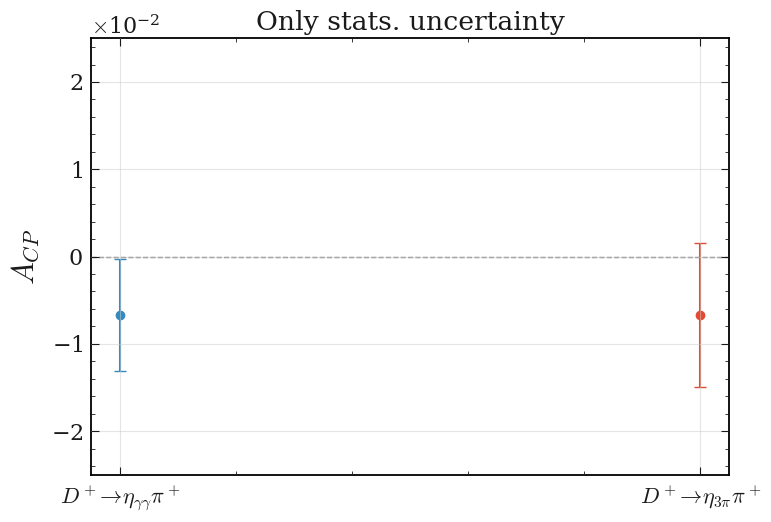

In [226]:
# Plotting
plt.errorbar(1, central_value_1, yerr=stat_unc_1, fmt='o', capsize=4)
plt.errorbar(2, central_value_2, yerr=stat_unc_2, fmt='o', capsize=4)
# plt.errorbar(3, combined_central_value, yerr=combined_error, fmt='o', capsize=4)

plt.axhline(y=0, color='gray', linestyle='--', linewidth=1)

# plt.xticks([1, 2, 3], [r'$D^+ \to \eta_{\gamma\gamma} \pi^+$', r'$D^+ \to \eta_{3\pi} \pi^+$', 'Combined'], fontsize=14)
plt.xticks([1, 2], [r'$D^+ \to \eta_{\gamma\gamma} \pi^+$', r'$D^+ \to \eta_{3\pi} \pi^+$'])

plt.gca().yaxis.set_major_formatter(ScalarFormatter(useMathText=True))
plt.ticklabel_format(axis="y", style="sci", scilimits=(0,0))

plt.ylabel(r'$A_{CP}$')
plt.grid(True, alpha=0.5)
plt.title("Only stats. uncertainty")

plt.ylim(-2.5*0.01 , 2.5*0.01)
plt.tight_layout()
plt.savefig("proc13_427_87_etapip_Acp_v7_fitv1_corr_Kshp_train_Dp_CMS_p_pdgKmix.png")
plt.show()

In [227]:
combined_central_value, combined_error = combine_error_weighted(central_value_1, central_value_2, stat_unc_1, stat_unc_2)


In [228]:
combined_central_value

-0.006685937814411306

In [229]:
combined_error

0.005072590989418199

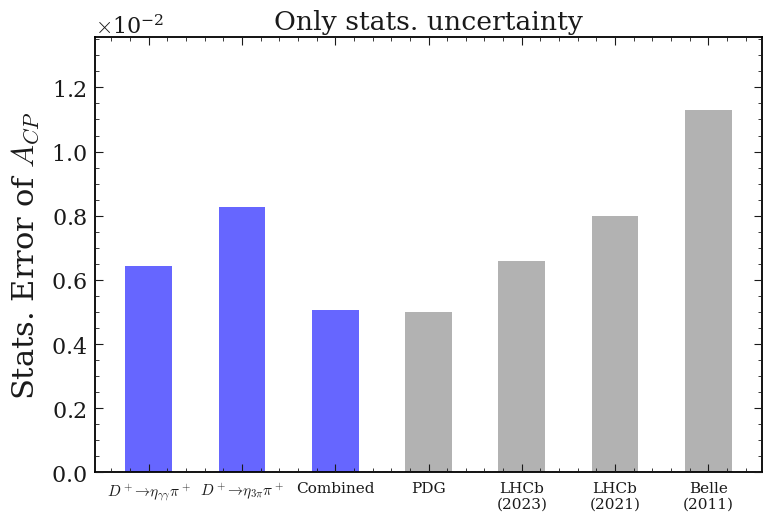

In [230]:
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter

# Define the errors as bar heights
errors = [stat_unc_1, stat_unc_2, combined_error, 0.005, 0.0066, 0.008,0.0113]

colors = ['blue', 'blue', 'blue', 'gray', 'gray', 'gray', 'gray', 'gray']

# Plotting error bars as a bar graph
plt.bar([1, 2, 3, 4, 5, 6,7], errors, color=colors , alpha=0.6, width=0.5)

# Adding a horizontal line at y=0
plt.axhline(y=0, color='gray', linestyle='--', linewidth=1)

# Customizing plot
plt.xticks([1, 2, 3, 4, 5, 6, 7], [r'$D^+ \to \eta_{\gamma\gamma} \pi^+$', r'$D^+ \to \eta_{3\pi} \pi^+$', 'Combined','PDG','LHCb\n(2023)','LHCb\n(2021)', 'Belle\n(2011)'], fontsize=11)
plt.gca().yaxis.set_major_formatter(ScalarFormatter(useMathText=True))
plt.ticklabel_format(axis="y", style="sci", scilimits=(0,0))

plt.ylabel(r'Stats. Error of $A_{CP}$')
# plt.grid(True, alpha=0.5)
plt.title("Only stats. uncertainty")

plt.ylim(0, max(errors) * 1.2)  # Adjusting y-limit to show error bars fully
plt.tight_layout()

# Save and display
plt.savefig("proc13_427_87_etapip_Acp_error_bars_v7_fitv11_corr_Kshp_train_Dp_CMS_p_pdgKmix.png")

plt.show()


## Acp(Ds+ -> eta pi+)

### eta -> gg

In [86]:
Araw_gg_cms_plus = 0
Araw_gg_cms_plus_error =  0.006048656667882429
Araw_gg_cms_minus = 0
Araw_gg_cms_minus_error =  0.006832845478790912
Araw_gg, Araw_gg_stats_error = combine_x_plus_y_divided_by_2(Araw_gg_cms_plus,Araw_gg_cms_minus, Araw_gg_cms_plus_error,Araw_gg_cms_minus_error )

In [87]:
Araw_gg

0.0

In [88]:
Araw_gg_stats_error

0.00456273012633204

In [234]:
# Aref_gg = 0.0020477180350933996
# Aref_gg_stats_error = 0.0021030268194965596

# Aref_gg_pdg = -0.0038
# Aref_gg_pdg_sys_error = 0.0027


In [235]:
# Acp_etapip_gg_value, Acp_etapip_gg_error =correct_Acp_stats_no_Kmix(Araw_gg, Araw_gg_stats_error, Aref_gg, Aref_gg_stats_error, Aref_gg_pdg)

In [30]:
Aref_gg_pdg = -0.0041
Aref_gg_pdg_sys_error = 0.0009

Aref_gg_cms_plus = -0.01838695653622552
Aref_gg_cms_plus_error = 0.002286733470408772
Aref_gg_cms_minus = 0.021078951054363085
Aref_gg_cms_minus_error = 0.0025704127770506922
Aref_gg, Aref_gg_stats_error = combine_x_plus_y_divided_by_2(Aref_gg_cms_plus,Aref_gg_cms_minus, Aref_gg_cms_plus_error,Aref_gg_cms_minus_error )

In [31]:
Aref_gg

0.0013459972590687836

In [32]:
Aref_gg_stats_error

0.0017201868945781152

In [237]:
Acp_etapip_gg_value, Acp_etapip_gg_error =correct_Acp_stats(Araw_gg, Araw_gg_stats_error, Aref_gg, Aref_gg_stats_error, Aref_gg_pdg, Aref_K_mix)

In [238]:
Acp_etapip_gg_value

-0.006703156703704864

In [239]:
Acp_etapip_gg_error

0.004643372419977062

### eta -> pipipi

In [240]:
# Araw_pipipi =  0.0003362131000147013
# Araw_pipipi_stats_error = 0.005709802050462188

In [98]:
Araw_3pi_cms_plus = 0
Araw_3pi_cms_plus_error = 0.008148069359353277
Araw_3pi_cms_minus = 0
Araw_3pi_cms_minus_error = 0.00898983134721261
Araw_pipipi, Araw_pipipi_stats_error = combine_x_plus_y_divided_by_2(Araw_3pi_cms_plus,Araw_3pi_cms_minus, Araw_3pi_cms_plus_error,Araw_3pi_cms_minus_error )

In [99]:
Araw_pipipi

0.0

In [100]:
Araw_pipipi_stats_error

0.006066467298522226

In [242]:
# Aref_3pi_cms_plus = 
# Aref_3pi_cms_plus_error = 
# Aref_3pi_cms_minus = 
# Aref_3pi_cms_minus_error =
# Aref_pipipi, Aref_pipipi_stats_error = combine_x_plus_y_divided_by_2(Aref_3pi_cms_plus,Aref_3pi_cms_minus, Aref_3pi_cms_plus_error,Aref_3pi_cms_minus_error )

In [243]:
# Aref_pipipi = 0.0020154684957205933
# Aref_pipipi_stats_error = 0.0019261952673341304

# Aref_pipipi_pdg = -0.0038
# Aref_pipipi_pdg_sys_error = 0.0027



In [244]:
# Acp_etapip_pipipi_value, Acp_etapip_pipipi_error =correct_Acp_stats_no_Kmix(Araw_pipipi, Araw_pipipi_stats_error, Aref_pipipi, Aref_pipipi_stats_error, Aref_pipipi_pdg)

In [245]:
Aref_pipipi_pdg = -0.0041
Aref_pipipi_pdg_sys_error = 0.0009

Aref_K_mix = -0.00070
Aref_K_mix_sys_error = 0.00004

In [246]:
Acp_etapip_pipipi_value, Acp_etapip_pipipi_error =correct_Acp_stats(Araw_pipipi, Araw_pipipi_stats_error, Aref_pipipi, Aref_pipipi_stats_error, Aref_pipipi_pdg, Aref_K_mix)

In [247]:
Acp_etapip_pipipi_value

-0.006657529328251396

In [248]:
Acp_etapip_pipipi_error

0.006114371138193916

In [249]:
central_value_1, central_value_2, stat_unc_1, stat_unc_2 = Acp_etapip_gg_value, Acp_etapip_pipipi_value, Acp_etapip_gg_error, Acp_etapip_pipipi_error

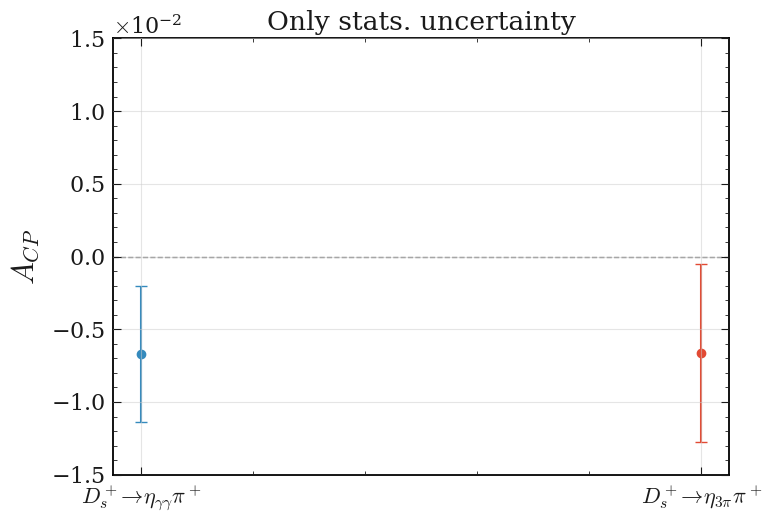

In [250]:
# Plotting
plt.errorbar(1, central_value_1, yerr=stat_unc_1, fmt='o', capsize=4)
plt.errorbar(2, central_value_2, yerr=stat_unc_2, fmt='o', capsize=4)
# plt.errorbar(3, combined_central_value, yerr=combined_error, fmt='o', capsize=4)

plt.axhline(y=0, color='gray', linestyle='--', linewidth=1)

# plt.xticks([1, 2, 3], [r'$D_s^+ \to \eta_{\gamma\gamma} \pi^+$', r'$D_s^+ \to \eta_{3\pi} \pi^+$', 'Combined'], fontsize=14)
plt.xticks([1, 2], [r'$D_s^+ \to \eta_{\gamma\gamma} \pi^+$', r'$D_s^+ \to \eta_{3\pi} \pi^+$'])

plt.gca().yaxis.set_major_formatter(ScalarFormatter(useMathText=True))
plt.ticklabel_format(axis="y", style="sci", scilimits=(0,0))

plt.ylabel(r'$A_{CP}$')
plt.grid(True, alpha=0.5)
plt.title("Only stats. uncertainty")

plt.ylim(-1.5*0.01 , 1.5*0.01)

plt.tight_layout()
plt.savefig("proc13_427_87_etapip_Acp_v7_fitv1_corr_Kshp_train_Dp_CMS_p_pdgKmix_Ds.png")
plt.show()

In [251]:
combined_central_value, combined_error = combine_error_weighted(central_value_1, central_value_2, stat_unc_1, stat_unc_2)


In [252]:
combined_central_value

-0.006686467526417103

In [253]:
combined_error

0.0036979115278772626

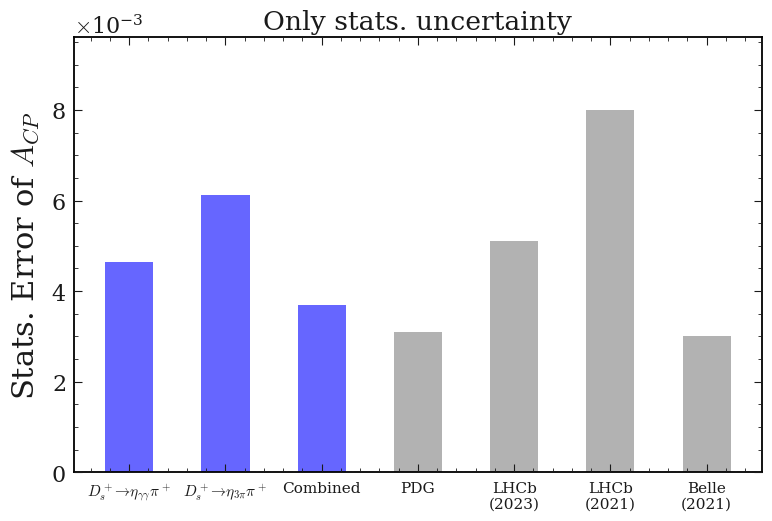

In [254]:
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter

# Define the errors as bar heights
errors = [stat_unc_1, stat_unc_2, combined_error, 0.0031,0.0051, 0.008, 0.003]

colors = ['blue', 'blue', 'blue', 'gray', 'gray', 'gray', 'gray','gray']
# Plotting error bars as a bar graph
plt.bar([1, 2, 3, 4, 5, 6, 7], errors, color=colors, alpha=0.6, width=0.5)

# Adding a horizontal line at y=0
plt.axhline(y=0, color='gray', linestyle='--', linewidth=1)

# Customizing plot
plt.xticks([1, 2, 3, 4, 5, 6,7], [r'$D_s^+ \to \eta_{\gamma\gamma} \pi^+$', r'$D_s^+ \to \eta_{3\pi} \pi^+$', 'Combined','PDG','LHCb\n(2023)','LHCb\n(2021)','Belle\n(2021)'], fontsize=11)
plt.gca().yaxis.set_major_formatter(ScalarFormatter(useMathText=True))
plt.ticklabel_format(axis="y", style="sci", scilimits=(0,0))

plt.ylabel(r'Stats. Error of $A_{CP}$')
# plt.grid(True, alpha=0.5)
plt.title("Only stats. uncertainty")

plt.ylim(0, max(errors) * 1.2)  # Adjusting y-limit to show error bars fully
plt.tight_layout()


# Save and display
plt.savefig("proc13_427_87_etapip_Acp_error_bars_v7_fitv11_corr_Kshp_train_Dp_CMS_p_pdgKmix_Ds.png")
plt.show()


In [ ]:
# def combine_error_weighted(x, y, x_err, y_err):

In [103]:
x = 0.33
x_err = 0.73
y = 0.08
y_err = 0.91
combine_error_weighted(x, y, x_err, y_err)

(0.23211241734019106, 0.5694232422393305)

In [12]:
x = 0.
x_err = 2.15
y = 0.0
y_err = 3.04
combine_error_weighted(x, y, x_err, y_err)

(0.0, 1.7553600189828684)

In [13]:
x = 0.33
x_err = 0.73
y = 0.12
y_err = 0.90
combine_error_weighted(x, y, x_err, y_err)

(0.24666617022860973, 0.566948398234863)

In [14]:
x = 0.10
x_err = 0.46
y = -0.10
y_err = 0.59
combine_error_weighted(x, y, x_err, y_err)

(0.02438806503484009, 0.36277068901285403)

In [14]:
x = 0.10
x_err = 0.46
y = -0.10
y_err = 0.59
combine_error_weighted(x, y, x_err, y_err)

(0.02438806503484009, 0.36277068901285403)

In [19]:
x = 9.25
x_err = 7.93
y = 2.40
y_err = 8.67
combine_error_weighted(x, y, x_err, y_err)

(6.129755827076112, 5.8515120288154625)

In [20]:
x = 1.71
x_err = 2.19
y = 1.17
y_err = 3.07
combine_error_weighted(x, y, x_err, y_err)

(1.527882427396104, 1.7828607421752638)

In [22]:
x = 0
x_err = 0.65
y = 0
y_err = 0.84
combine_error_weighted(x, y, x_err, y_err)

(0.0, 0.5140659553015954)

In [23]:
x = 0
x_err = 0.49
y = 0
y_err = 0.63
combine_error_weighted(x, y, x_err, y_err)

(0.0, 0.3867825865143999)

In [ ]:
# def combine_x_plus_y_divided_by_2(x, y, x_err, y_err):
#     central_value = (x+y)/2
#     error = sqrt(x_err**2 +  y_err**2)/2
#     return central_value, error

In [7]:
x = 0
x_err = 0.83
y = 0
y_err = 0.94
combine_x_plus_y_divided_by_2(x, y, x_err, y_err)

(0.0, 0.6269968101992226)

In [9]:
x = 0.
x_err = 0.61
y = 0.
y_err = 0.69
combine_x_plus_y_divided_by_2(x, y, x_err, y_err)

(0.0, 0.46048887065813)

In [12]:
x = -1.74
x_err = 0.23
y = 2.01
y_err = 0.26
combine_x_plus_y_divided_by_2(x, y, x_err, y_err)

(0.1349999999999999, 0.17356554957709783)

In [13]:
x = -1.80
x_err = 0.21
y = 2.30
y_err = 0.23
combine_x_plus_y_divided_by_2(x, y, x_err, y_err)

(0.2499999999999999, 0.15572411502397437)

In [14]:
x = -1.92
x_err = 0.64
y = 2.02
y_err = 0.67
combine_x_plus_y_divided_by_2(x, y, x_err, y_err)

(0.050000000000000044, 0.4632763753959401)

In [15]:
x = -2.51
x_err = 0.61
y = 2.68
y_err = 0.65
combine_x_plus_y_divided_by_2(x, y, x_err, y_err)

(0.08500000000000019, 0.445701693961331)

In [16]:
x = 0
x_err = 1.10
y = 0
y_err = 1.22
combine_x_plus_y_divided_by_2(x, y, x_err, y_err)

(0.0, 0.8213403679352428)

In [17]:
x = 0
x_err = 0.81
y = 0
y_err = 0.90
combine_x_plus_y_divided_by_2(x, y, x_err, y_err)

(0.0, 0.605413082118317)

In [7]:
def Acp_cal_basic(sig, ref, sig_err, ref_err):
    central_value = sig - ref
    error = sqrt(sig_err**2 +  ref_err**2)
    return central_value, error

In [8]:
sig = 0.56
sig_err = 0.70
ref = 0.23
ref_err = 0.19
Acp_cal_basic(sig, ref, sig_err, ref_err)

(0.33000000000000007, 0.7253275122315435)

In [9]:
sig = 0.32
sig_err = 0.88
ref = 0.20
ref_err = 0.17
Acp_cal_basic(sig, ref, sig_err, ref_err)

(0.12, 0.8962700485902673)

In [10]:
sig = 0.33
sig_err = 0.42
ref = 0.23
ref_err = 0.19
Acp_cal_basic(sig, ref, sig_err, ref_err)

(0.1, 0.4609772228646443)

In [11]:
sig = 0.10
sig_err = 0.56
ref = 0.20
ref_err = 0.17
Acp_cal_basic(sig, ref, sig_err, ref_err)

(-0.1, 0.5852349955359812)

In [15]:
sig = 10.00
sig_err = 7.92
ref = 0.75
ref_err = 0.41
Acp_cal_basic(sig, ref, sig_err, ref_err)

(9.25, 7.930605273243651)

In [16]:
sig = 3.02
sig_err = 8.66
ref = 0.62
ref_err = 0.40
Acp_cal_basic(sig, ref, sig_err, ref_err)

(2.4, 8.669232953381746)

In [17]:
sig = 2.46
sig_err = 2.15
ref = 0.75
ref_err = 0.41
Acp_cal_basic(sig, ref, sig_err, ref_err)

(1.71, 2.1887439320304236)

In [18]:
sig = 1.79
sig_err = 3.04
ref = 0.62
ref_err = 0.40
Acp_cal_basic(sig, ref, sig_err, ref_err)

(1.17, 3.066202863477888)

In [22]:
x = 0.55
x_err = 0.93
y = 0.56
y_err = 1.05
combine_x_plus_y_divided_by_2(x, y, x_err, y_err)

(0.555, 0.7013201836536576)

In [24]:
x = -0.35
x_err = 0.57
y = 1.01
y_err = 0.62
combine_x_plus_y_divided_by_2(x, y, x_err, y_err)

(0.33, 0.4210997506529777)

In [25]:
x = -0.21
x_err = 1.19
y = 0.84
y_err = 1.31
combine_x_plus_y_divided_by_2(x, y, x_err, y_err)

(0.315, 0.8849011244201241)

In [26]:
x = -0.21
x_err = 0.75
y = 0.40
y_err = 0.82
combine_x_plus_y_divided_by_2(x, y, x_err, y_err)

(0.09500000000000001, 0.5556302727533841)

In [27]:
x = 8.91
x_err = 11.70
y = 11.10
y_err = 10.68
combine_x_plus_y_divided_by_2(x, y, x_err, y_err)

(10.004999999999999, 7.920738601923434)

In [28]:
x = 1.74
x_err = 2.97
y = 3.18
y_err = 3.10
combine_x_plus_y_divided_by_2(x, y, x_err, y_err)

(2.46, 2.146561203413497)

In [29]:
x = -7.62
x_err = 12.47
y = 13.65
y_err = 12.01
combine_x_plus_y_divided_by_2(x, y, x_err, y_err)

(3.015, 8.656514887643873)

In [30]:
x = -0.68
x_err = 4.21
y = 4.25
y_err = 4.40
combine_x_plus_y_divided_by_2(x, y, x_err, y_err)

(1.785, 3.0448357919598887)

In [31]:
x = -0.46
x_err = 0.26
y = 0.92
y_err = 0.28
combine_x_plus_y_divided_by_2(x, y, x_err, y_err)

(0.23, 0.19104973174542803)

In [32]:
x = -0.69
x_err = 0.12
y = 0.97
y_err = 0.13
combine_x_plus_y_divided_by_2(x, y, x_err, y_err)

(0.14, 0.08845903006477067)

In [33]:
x = -0.55
x_err = 0.23
y = 0.94
y_err = 0.25
combine_x_plus_y_divided_by_2(x, y, x_err, y_err)

(0.19499999999999995, 0.1698528775146303)

In [34]:
x = -0.33
x_err = 0.57
y = 1.83
y_err = 0.59
combine_x_plus_y_divided_by_2(x, y, x_err, y_err)

(0.75, 0.4101828860398737)

In [35]:
x = -0.44
x_err = 0.55
y = 1.68
y_err = 0.58
combine_x_plus_y_divided_by_2(x, y, x_err, y_err)

(0.62, 0.3996561021678513)

In [36]:
x = 0
x_err = 0.83
y = 0
y_err = 0.94
combine_x_plus_y_divided_by_2(x, y, x_err, y_err)

(0.0, 0.6269968101992226)

In [37]:
x = 0
x_err = 0.61
y = 0
y_err = 0.69
combine_x_plus_y_divided_by_2(x, y, x_err, y_err)

(0.0, 0.46048887065813)

In [38]:
x = 0
x_err = 1.1
y = 0
y_err = 1.22
combine_x_plus_y_divided_by_2(x, y, x_err, y_err)

(0.0, 0.8213403679352428)

In [39]:
x = 0
x_err = 0.81
y = 0
y_err = 0.90
combine_x_plus_y_divided_by_2(x, y, x_err, y_err)

(0.0, 0.605413082118317)

In [40]:
x = -1.74
x_err = 0.23
y = 2.01
y_err = 0.26
combine_x_plus_y_divided_by_2(x, y, x_err, y_err)

(0.1349999999999999, 0.17356554957709783)

In [41]:
x = -1.80
x_err = 0.21
y = 2.30
y_err = 0.23
combine_x_plus_y_divided_by_2(x, y, x_err, y_err)

(0.2499999999999999, 0.15572411502397437)

In [42]:
x = -1.92
x_err = 0.64
y = 2.02
y_err = 0.67
combine_x_plus_y_divided_by_2(x, y, x_err, y_err)

(0.050000000000000044, 0.4632763753959401)

In [43]:
x = -2.51
x_err = 0.61
y = 2.68
y_err = 0.65
combine_x_plus_y_divided_by_2(x, y, x_err, y_err)

(0.08500000000000019, 0.445701693961331)